In [84]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

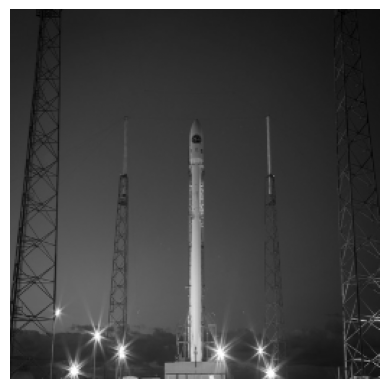

In [89]:
# Load rocket image (RGB → grayscale)
image = data.rocket()
image = resize(image, (256, 256))
image = color.rgb2gray(image)

# Get size
M, N = image.shape

# Show image
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

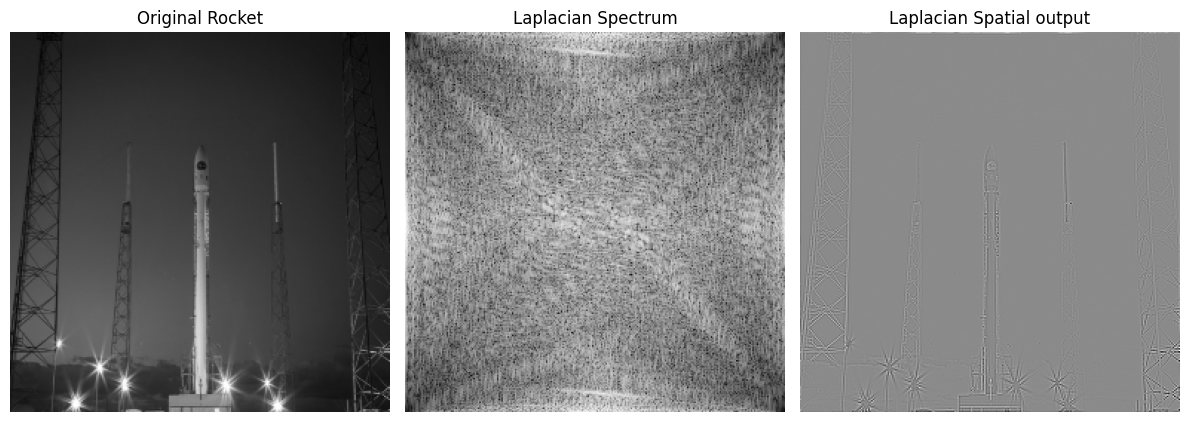

In [90]:
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

F = np.fft.fft2(image)
F_lap = F * laplacian_filter

laplacian_image = np.fft.ifft2(F_lap).real

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Rocket')
plt.axis('off')


plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian Spatial output')
plt.axis('off')
plt.tight_layout()
plt.show()

In [91]:
#Sobel filters 
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

In [92]:
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    cy, cx = ph // 2, pw // 2
    
    # Places kernel at center 
    padded[cy - kh//2 : cy - kh//2 + kh,
           cx - kw//2 : cx - kw//2 + kw] = kernel
    
    # Shifts kernel then apply FFT
    return fft2(ifftshift(padded))

In [93]:
# FFT of image
F = fft2(image)

# FFT of Sobel filters
Hx = center_embed_kernel(sobel_x, (M, N))
Hy = center_embed_kernel(sobel_y, (M, N))


Gx = F * Hx
Gy = F * Hy

gx = np.real(ifft2(Gx))
gy = np.real(ifft2(Gy))

# Combines Sobel X and Y
magnitude = np.sqrt(gx**2 + gy**2)

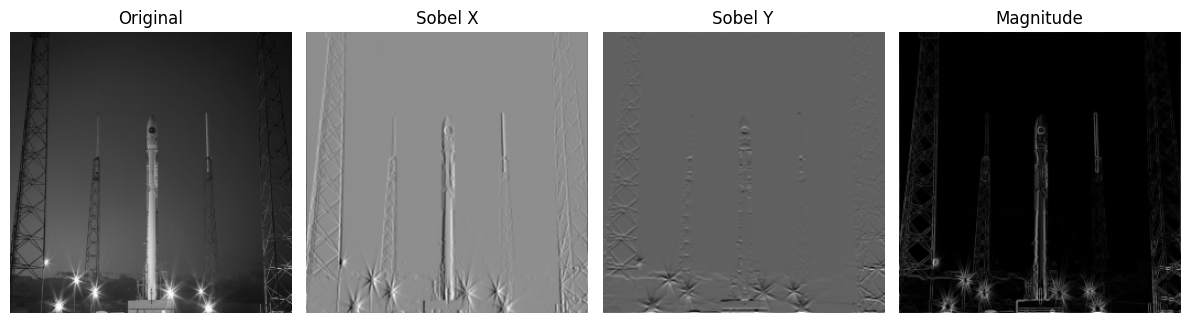

In [94]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gx, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gy, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()